In [1]:
from pathlib import Path

folder = Path(r"D:\Sem_5\DSIP\Practical_Code\OEP_8")

print("Folder exists:", folder.exists())
print("Folder path:", folder)

for i in range(1, 6):
    file = folder / f"image{i}.jpg"
    print(f"image{i}.jpg ->", file.exists())

Folder exists: True
Folder path: D:\Sem_5\DSIP\Practical_Code\OEP_8
image1.jpg -> True
image2.jpg -> True
image3.jpg -> True
image4.jpg -> True
image5.jpg -> True


In [2]:
import cv2

images = []

for i in range(1, 6):
    path = folder / f"image{i}.jpg"

    image = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise ValueError(
            f"Could not load image{i}.jpg"
        )

    images.append(image)

print("Images loaded successfully!")
print("Total images:", len(images))

for i, image in enumerate(images, 1):
    print(
        f"Image {i}: "
        f"Size = {image.shape[1]} x {image.shape[0]}"
    )

Images loaded successfully!
Total images: 5
Image 1: Size = 5304 x 7952
Image 2: Size = 3000 x 2000
Image 3: Size = 3243 x 4896
Image 4: Size = 6016 x 4016
Image 5: Size = 6683 x 5331


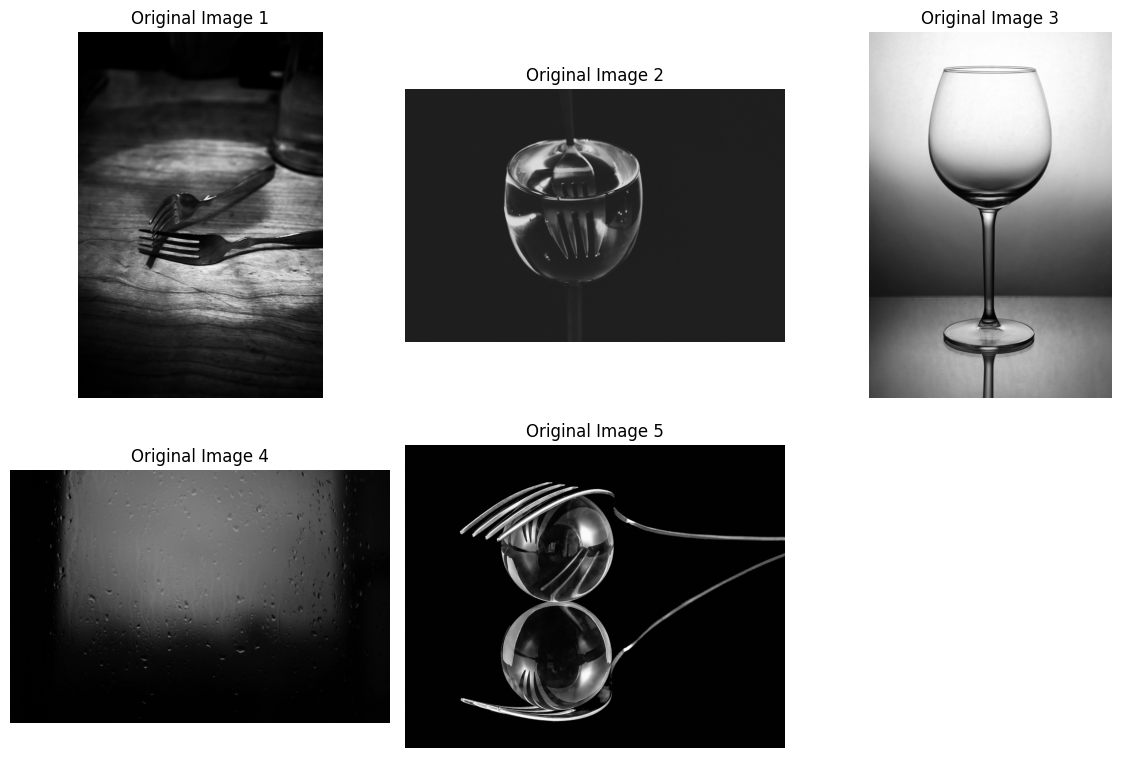

5 images displayed successfully.
Image 1: 667 x 999
Image 2: 1000 x 666
Image 3: 662 x 1000
Image 4: 1000 x 667
Image 5: 1000 x 797


In [4]:
# ============================================================
# STEP 3 - RESIZE AND DISPLAY THE 5 ORIGINAL IMAGES
# ============================================================

import matplotlib.pyplot as plt
import cv2

# Maximum size for processing/display
MAX_SIZE = 1000

display_images = []

for image in images:

    height, width = image.shape

    # Resize only if image is too large
    if max(height, width) > MAX_SIZE:

        scale = MAX_SIZE / max(height, width)

        new_width = int(width * scale)
        new_height = int(height * scale)

        resized = cv2.resize(
            image,
            (new_width, new_height),
            interpolation=cv2.INTER_AREA
        )

    else:
        resized = image.copy()

    display_images.append(resized)


# Replace original images with resized versions
images = display_images


# Display images
plt.figure(figsize=(12, 8))

for i in range(5):

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        images[i],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    plt.title(f"Original Image {i + 1}")

    plt.axis("off")


plt.tight_layout()

plt.show()


print("5 images displayed successfully.")

for i, image in enumerate(images, 1):

    print(
        f"Image {i}: "
        f"{image.shape[1]} x {image.shape[0]}"
    )

In [5]:
# ============================================================
# STEP 4 - HISTOGRAM EQUALIZATION
# ============================================================

equalized_images = []

for image in images:

    # Apply Histogram Equalization
    equalized = cv2.equalizeHist(image)

    equalized_images.append(equalized)


print("Histogram Equalization completed successfully.")
print("Total images processed:", len(equalized_images))

Histogram Equalization completed successfully.
Total images processed: 5


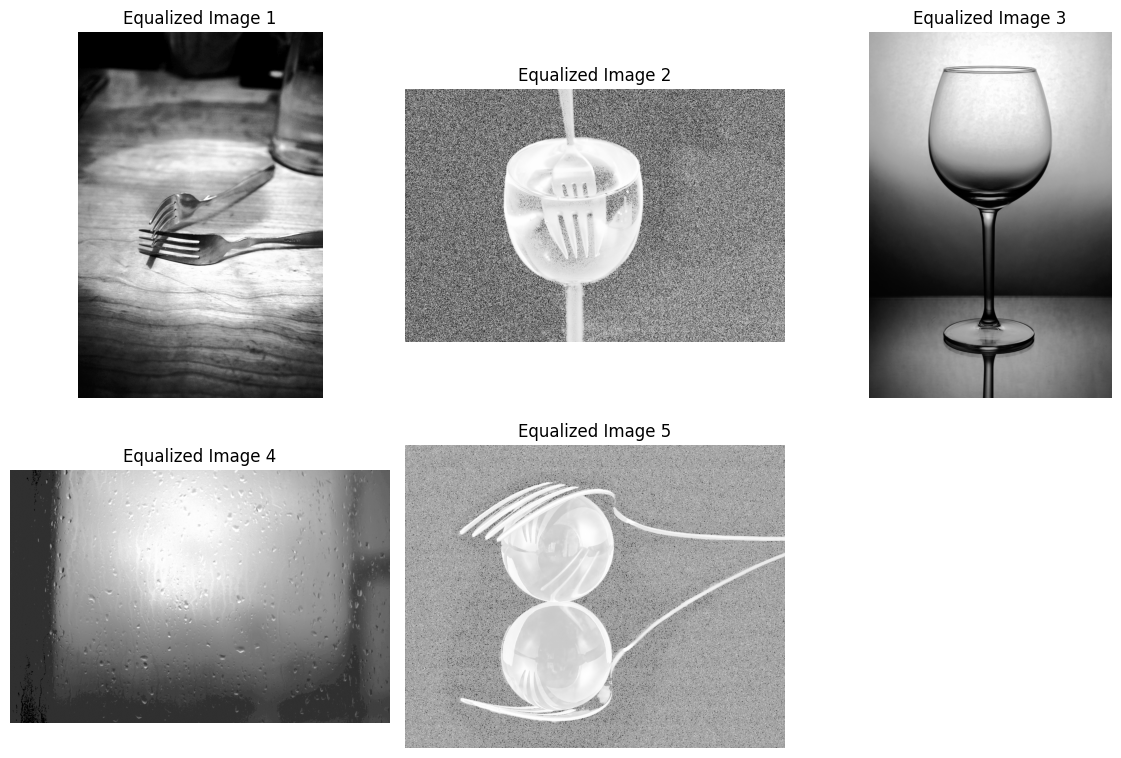

5 Histogram Equalized images displayed successfully.


In [6]:
# ============================================================
# STEP 5 - DISPLAY HISTOGRAM EQUALIZED IMAGES
# ============================================================

plt.figure(figsize=(12, 8))

for i in range(5):

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        equalized_images[i],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    plt.title(
        f"Equalized Image {i + 1}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print("5 Histogram Equalized images displayed successfully.")

In [8]:
# ============================================================
# STEP 6 - HISTOGRAM MATCHING
# ============================================================

import numpy as np
from skimage.exposure import match_histograms

# Use Image 1 as the reference image
reference_image = images[0]

matched_images = []

for image in images:

    matched = match_histograms(
        image,
        reference_image,
        channel_axis=None
    )

    # Convert safely to 8-bit grayscale
    matched = np.clip(
        matched,
        0,
        255
    ).astype(np.uint8)

    matched_images.append(matched)

print("Histogram Matching completed successfully.")
print("Total images processed:", len(matched_images))

Histogram Matching completed successfully.
Total images processed: 5


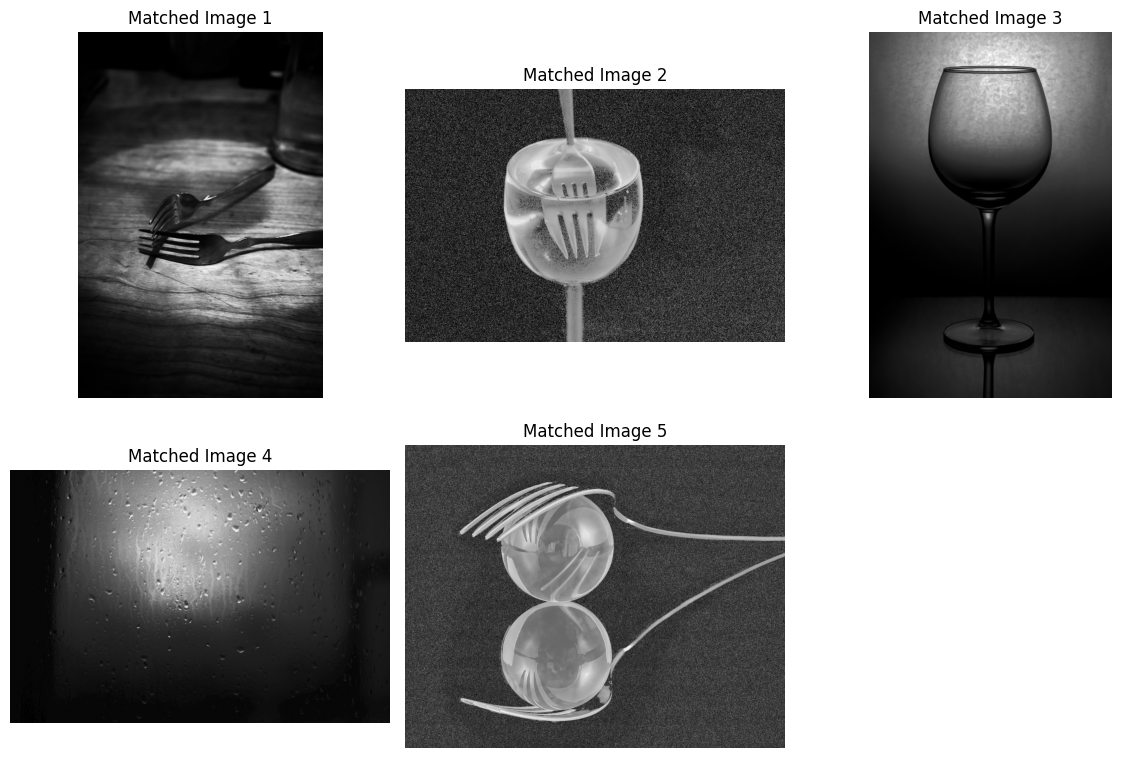

5 Histogram Matched images displayed successfully.


In [9]:
# ============================================================
# STEP 7 - DISPLAY HISTOGRAM MATCHING RESULTS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(5):

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        matched_images[i],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    plt.title(
        f"Matched Image {i + 1}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print("5 Histogram Matched images displayed successfully.")

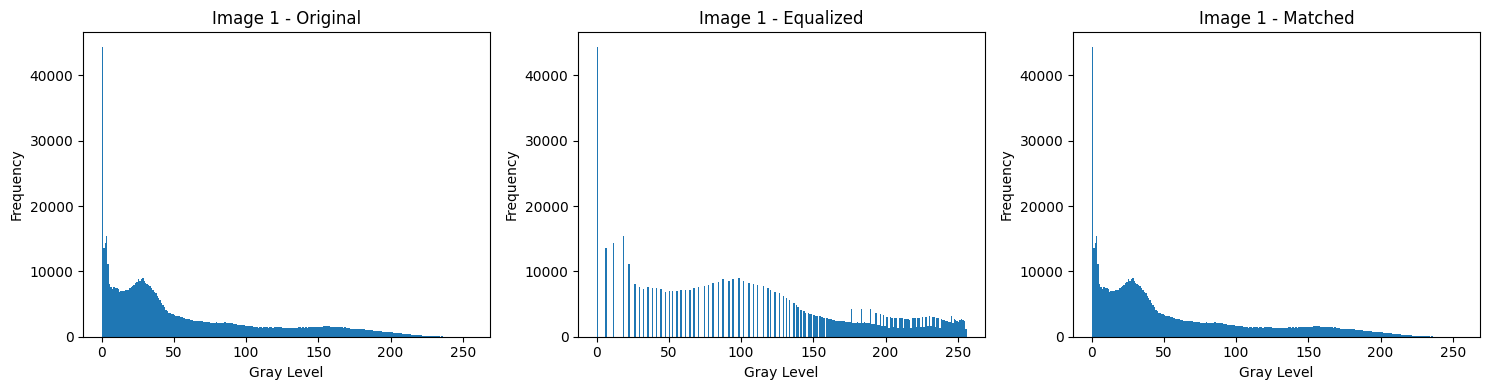

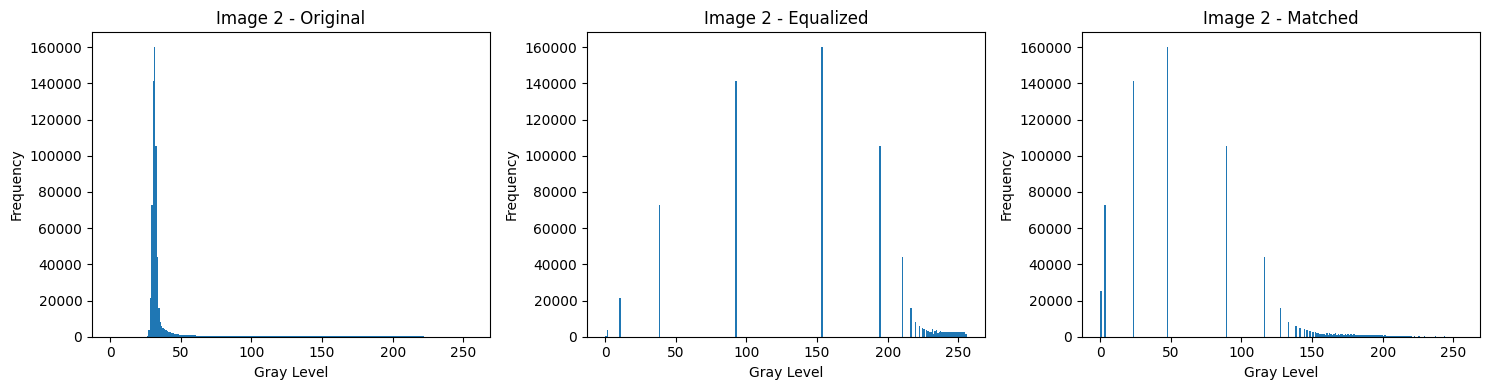

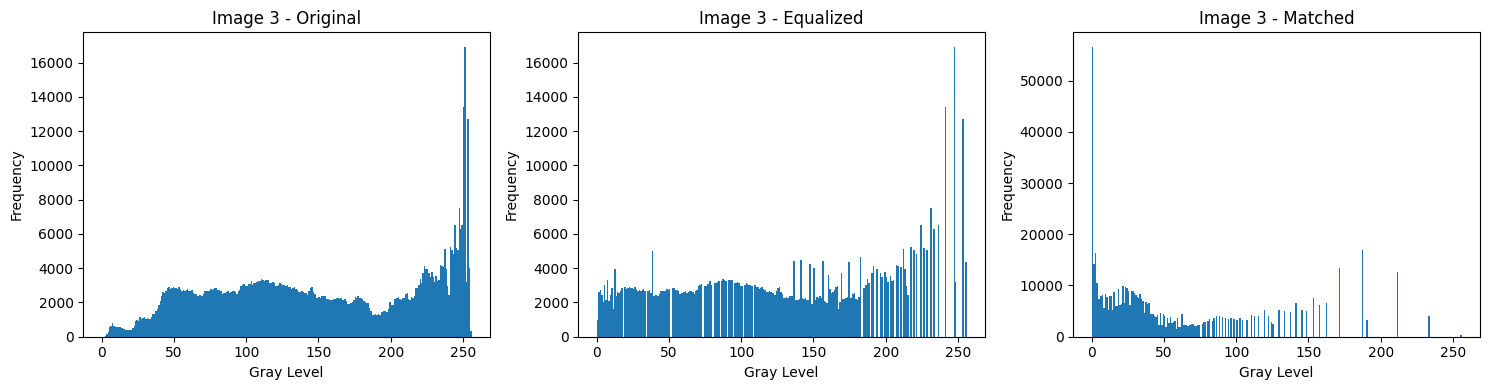

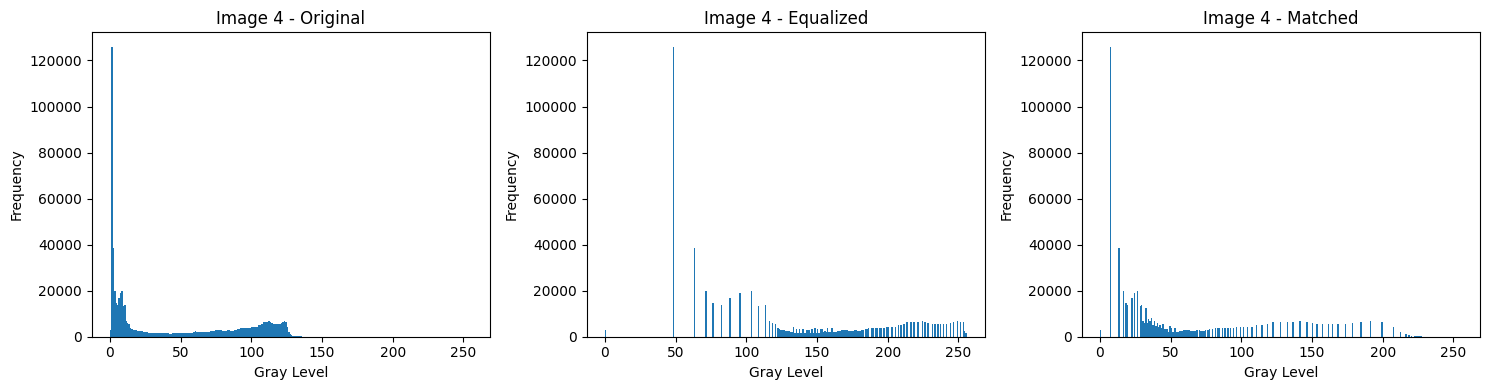

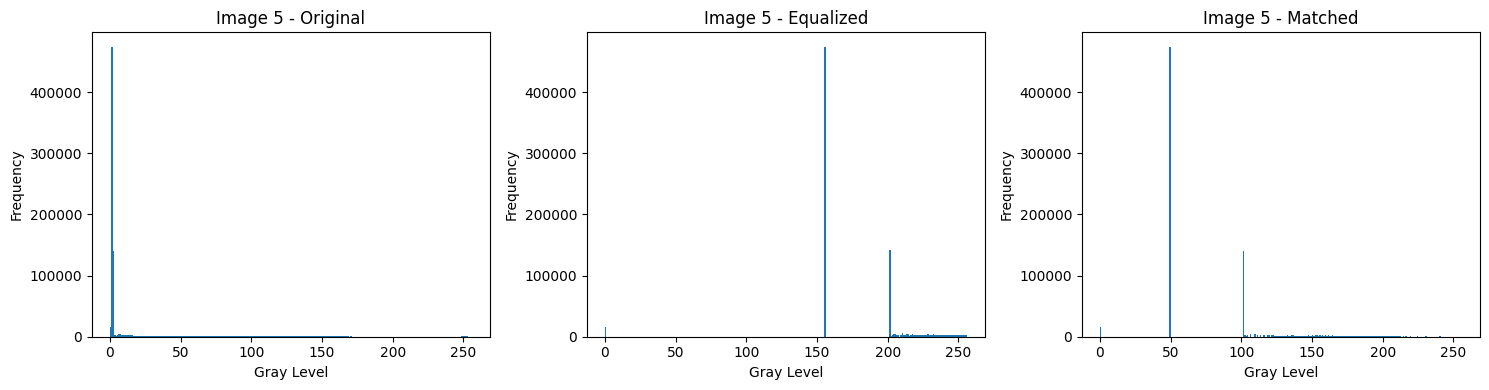

Histogram comparison completed successfully.


In [10]:
# ============================================================
# STEP 8 - HISTOGRAM COMPARISON
# ============================================================

import matplotlib.pyplot as plt

for i in range(5):

    plt.figure(figsize=(15, 4))

    # --------------------------------------------------------
    # Original Histogram
    # --------------------------------------------------------

    plt.subplot(1, 3, 1)

    plt.hist(
        images[i].ravel(),
        bins=256,
        range=(0, 256)
    )

    plt.title(
        f"Image {i + 1} - Original"
    )

    plt.xlabel("Gray Level")
    plt.ylabel("Frequency")


    # --------------------------------------------------------
    # Histogram Equalization
    # --------------------------------------------------------

    plt.subplot(1, 3, 2)

    plt.hist(
        equalized_images[i].ravel(),
        bins=256,
        range=(0, 256)
    )

    plt.title(
        f"Image {i + 1} - Equalized"
    )

    plt.xlabel("Gray Level")
    plt.ylabel("Frequency")


    # --------------------------------------------------------
    # Histogram Matching
    # --------------------------------------------------------

    plt.subplot(1, 3, 3)

    plt.hist(
        matched_images[i].ravel(),
        bins=256,
        range=(0, 256)
    )

    plt.title(
        f"Image {i + 1} - Matched"
    )

    plt.xlabel("Gray Level")
    plt.ylabel("Frequency")


    plt.tight_layout()
    plt.show()


print("Histogram comparison completed successfully.")

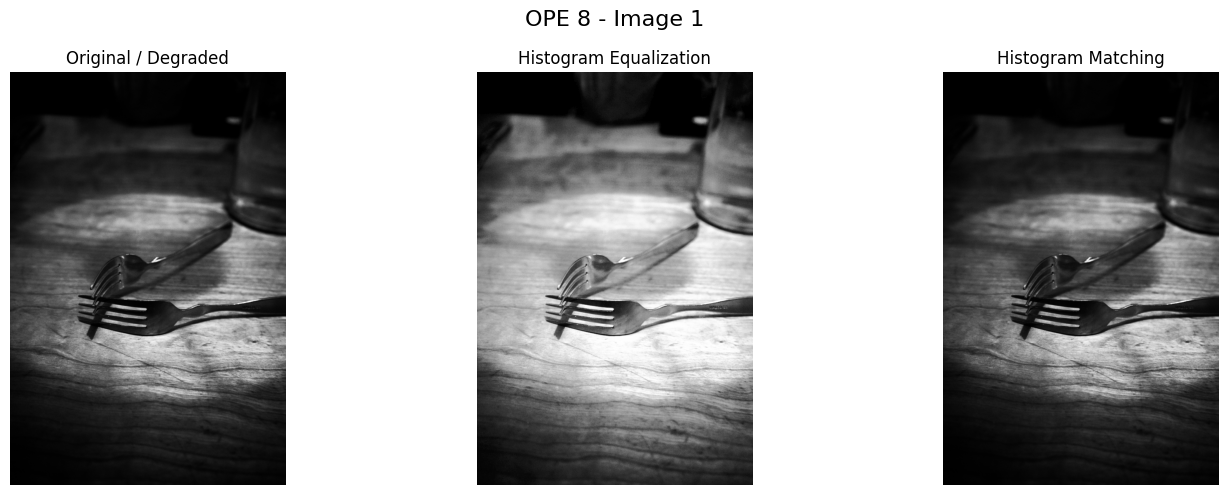

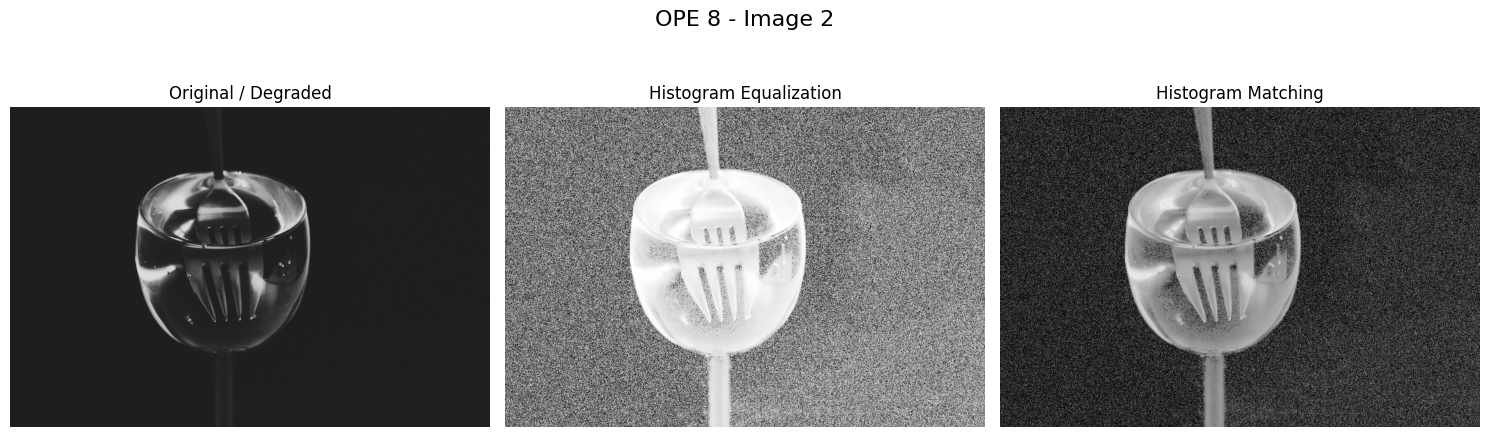

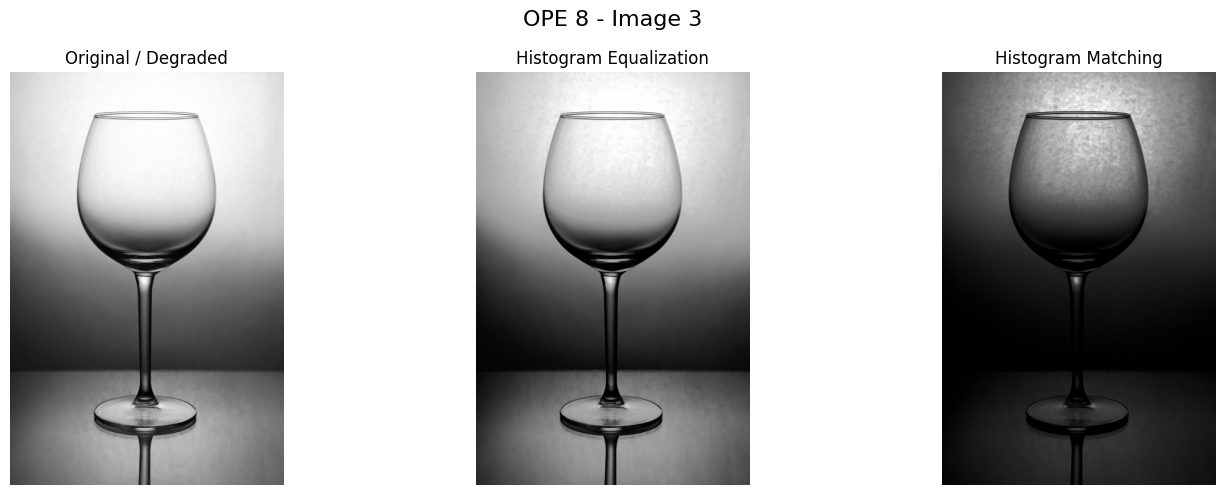

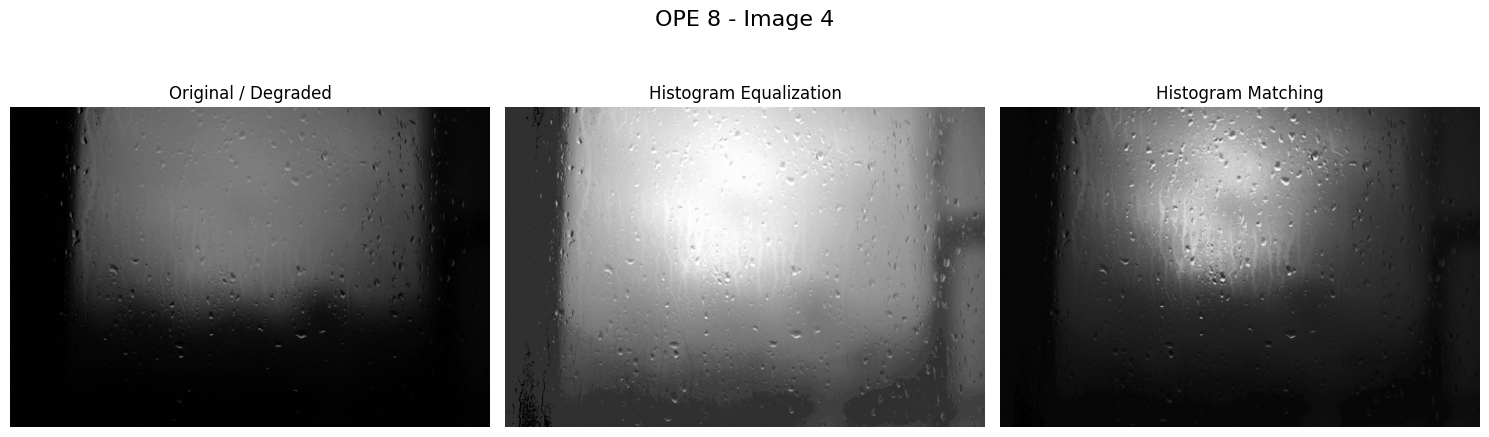

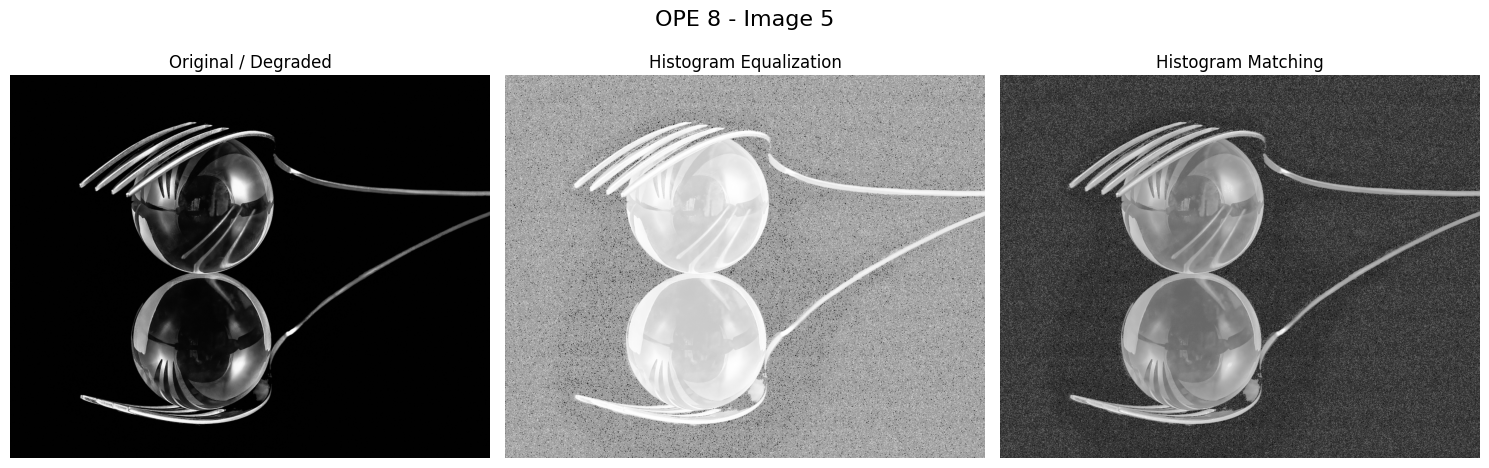

Final visual comparison completed successfully.


In [11]:
# ============================================================
# STEP 9 - FINAL VISUAL COMPARISON
# ============================================================

import matplotlib.pyplot as plt

for i in range(5):

    plt.figure(figsize=(15, 5))

    # --------------------------------------------------------
    # Original
    # --------------------------------------------------------

    plt.subplot(1, 3, 1)

    plt.imshow(
        images[i],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    plt.title("Original / Degraded")
    plt.axis("off")


    # --------------------------------------------------------
    # Histogram Equalization
    # --------------------------------------------------------

    plt.subplot(1, 3, 2)

    plt.imshow(
        equalized_images[i],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    plt.title("Histogram Equalization")
    plt.axis("off")


    # --------------------------------------------------------
    # Histogram Matching
    # --------------------------------------------------------

    plt.subplot(1, 3, 3)

    plt.imshow(
        matched_images[i],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    plt.title("Histogram Matching")
    plt.axis("off")


    plt.suptitle(
        f"OPE 8 - Image {i + 1}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


print("Final visual comparison completed successfully.")

In [12]:
# ============================================================
# STEP 10 - NUMERICAL CONTRAST COMPARISON
# ============================================================

import numpy as np

for i in range(5):

    original = images[i]
    equalized = equalized_images[i]
    matched = matched_images[i]

    print("=" * 60)
    print(f"IMAGE {i + 1}")
    print("=" * 60)

    print("\nORIGINAL")
    print("Minimum intensity :", int(original.min()))
    print("Maximum intensity :", int(original.max()))
    print("Mean intensity    :", round(float(original.mean()), 2))
    print("Contrast (Std Dev):", round(float(original.std()), 2))

    print("\nHISTOGRAM EQUALIZATION")
    print("Minimum intensity :", int(equalized.min()))
    print("Maximum intensity :", int(equalized.max()))
    print("Mean intensity    :", round(float(equalized.mean()), 2))
    print("Contrast (Std Dev):", round(float(equalized.std()), 2))

    print("\nHISTOGRAM MATCHING")
    print("Minimum intensity :", int(matched.min()))
    print("Maximum intensity :", int(matched.max()))
    print("Mean intensity    :", round(float(matched.mean()), 2))
    print("Contrast (Std Dev):", round(float(matched.std()), 2))

    print()

IMAGE 1

ORIGINAL
Minimum intensity : 0
Maximum intensity : 255
Mean intensity    : 56.73
Contrast (Std Dev): 56.3

HISTOGRAM EQUALIZATION
Minimum intensity : 0
Maximum intensity : 255
Mean intensity    : 120.08
Contrast (Std Dev): 77.37

HISTOGRAM MATCHING
Minimum intensity : 0
Maximum intensity : 255
Mean intensity    : 56.73
Contrast (Std Dev): 56.3

IMAGE 2

ORIGINAL
Minimum intensity : 25
Maximum intensity : 224
Mean intensity    : 38.35
Contrast (Std Dev): 27.65

HISTOGRAM EQUALIZATION
Minimum intensity : 0
Maximum intensity : 255
Mean intensity    : 146.22
Contrast (Std Dev): 68.03

HISTOGRAM MATCHING
Minimum intensity : 0
Maximum intensity : 255
Mean intensity    : 66.33
Contrast (Std Dev): 54.85

IMAGE 3

ORIGINAL
Minimum intensity : 2
Maximum intensity : 255
Mean intensity    : 151.0
Contrast (Std Dev): 71.85

HISTOGRAM EQUALIZATION
Minimum intensity : 0
Maximum intensity : 255
Mean intensity    : 128.2
Contrast (Std Dev): 73.97

HISTOGRAM MATCHING
Minimum intensity : 0
Maxim

In [13]:
# ============================================================
# STEP 11 - SAVE ALL OPE8 RESULTS
# ============================================================

from pathlib import Path
import cv2

# Create result folder
result_folder = folder / "OPE8_Results"

result_folder.mkdir(
    exist_ok=True
)

# Save original, equalized and matched images
for i in range(5):

    # Original
    cv2.imwrite(
        str(result_folder / f"Image_{i+1}_Original.png"),
        images[i]
    )

    # Histogram Equalization
    cv2.imwrite(
        str(result_folder / f"Image_{i+1}_Equalized.png"),
        equalized_images[i]
    )

    # Histogram Matching
    cv2.imwrite(
        str(result_folder / f"Image_{i+1}_Matched.png"),
        matched_images[i]
    )

print("All images saved successfully.")
print()
print("Results folder:")
print(result_folder)

All images saved successfully.

Results folder:
D:\Sem_5\DSIP\Practical_Code\OEP_8\OPE8_Results
